# 📊 Context & Conflict: The $287 Million Battlefield

**Notebook Purpose**: This notebook establishes the **context and conflict** for our data storytelling journey - showing why traditional fraud detection fails catastrophically on blockchain data.

**Key Questions We Answer**:
1. What does extreme class imbalance look like? (1:543 ratio)
2. Why does a "99.8% accurate" model fail completely?
3. Why do blockchain distributions break traditional statistics?

**Expected Visualizations**:
- Visualization 1.1: Class imbalance proportional area chart
- Visualization 1.2: Baseline model failure confusion matrix
- Visualization 1.3: Power-law distribution analysis (3 panels)

---

## 🔧 Setup: Import Libraries and Load Data

This cell imports all necessary libraries for data analysis and visualization.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Define data paths
DATA_ROOT = Path('../data')
FEATURES_PATH = DATA_ROOT / 'dataset' / 'Data_after_FE' / 'features.csv'
PHISHER_PATH = DATA_ROOT / 'raw_data' / 'phisher_accounts.txt'

# Create output directory if it doesn't exist
import os
os.makedirs('save_image_story', exist_ok=True)

print("✅ Libraries imported successfully")
print(f"📂 Data root: {DATA_ROOT.absolute()}")

✅ Libraries imported successfully
📂 Data root: d:\Desktop_informations\SGK năm 3\SGK kì 1 năm 3\Visualization -teacher Long\Project final\final_project_notebook\Data-Prep-Project-main\data_storytelling_notebook\..\data


### Load Dataset with Features

Loading the engineered features dataset to understand our data landscape.

**Code Explanation:** This cell loads the feature-engineered dataset (`features.csv` with 34 behavioral features per address) and the list of known phisher accounts. It creates a binary label column (`is_phisher`) by matching the `node_id` column (which contains Ethereum addresses) against the phisher list. The output provides key statistics about class distribution and the severe imbalance ratio.

In [2]:
# Load the features dataset
df = pd.read_csv(FEATURES_PATH)

# Load address-to-index mapping
import pickle
MAPPING_PATH = DATA_ROOT / 'processed_data' / 'data_Dataset.address_to_index'
with open(MAPPING_PATH, 'rb') as f:
    address_to_index = pickle.load(f)

# Load phisher addresses and convert to indices
with open(PHISHER_PATH, 'r') as f:
    phisher_hex_addresses = set([line.strip().lower() for line in f.readlines()])

# Convert hex addresses to indices (try both as-is and lowercase keys)
phisher_indices = set()
not_found = []
for addr in phisher_hex_addresses:
    # Try exact match first
    if addr in address_to_index:
        phisher_indices.add(address_to_index[addr])
    # Try checking if keys in mapping are not lowercase
    elif any(addr == k.lower() for k in address_to_index.keys()):
        # Find the actual key
        for k in address_to_index.keys():
            if addr == k.lower():
                phisher_indices.add(address_to_index[k])
                break
    else:
        not_found.append(addr)

print(f"🔍 Phisher address conversion:")
print(f"   Hex addresses loaded: {len(phisher_hex_addresses):,}")
print(f"   Successfully mapped to indices: {len(phisher_indices):,}")
if len(not_found) > 0:
    print(f"   ⚠️  Not found in mapping: {len(not_found):,} addresses")
if len(phisher_indices) == 0:
    print("   ❌ ERROR: No phisher indices found! Please check address mapping file.")

# Create is_phisher label using node_id (which are indices)
df['is_phisher'] = df['node_id'].isin(phisher_indices).astype(int)

# Calculate statistics
n_phishers = df['is_phisher'].sum()
n_normal = (1-df['is_phisher']).sum()
phisher_pct = df['is_phisher'].mean()*100
normal_pct = (1-df['is_phisher'].mean())*100

print(f"\n📊 Dataset loaded: {len(df):,} addresses")
print(f"🔴 Phishers: {n_phishers:,} ({phisher_pct:.3f}%)")
print(f"🔵 Normal: {n_normal:,} ({normal_pct:.3f}%)")

# Validation check
if n_phishers == 0:
    print("\n❌ WARNING: No phisher accounts found in dataset!")
    print("   This will cause visualizations to show 'nan' values.")
    print("   Possible causes:")
    print("   1. Address-to-index mapping mismatch")
    print("   2. Phisher addresses not present in features.csv")
    print("   3. Case sensitivity issues in address matching")

# Safely calculate ratio (avoid division by zero)
if n_phishers > 0:
    ratio = int(n_normal / n_phishers)
    print(f"⚖️ Class Ratio (Normal:Phisher): {ratio}:1")
else:
    print(f"⚠️ WARNING: No phishers found in dataset!")
    
print(f"\n📋 Features available: {df.shape[1]}")

🔍 Phisher address conversion:
   Hex addresses loaded: 5,480
   Successfully mapped to indices: 5,480

📊 Dataset loaded: 825,820 addresses
🔴 Phishers: 5,480 (0.664%)
🔵 Normal: 820,340 (99.336%)
⚖️ Class Ratio (Normal:Phisher): 149:1

📋 Features available: 36


---

## 📊 Visualization 1.1: The Invisible Minority (Class Imbalance)

**Purpose**: Show the extreme class imbalance - phishers are like finding 1 person in 5 sold-out NFL stadiums.

**Chart Type**: Proportional area chart with dramatic size contrast

**Pre-attentive Attributes**: 
- Size disparity (tiny red dot vs massive blue circle)
- Color coding (red = danger, blue = normal)
- Center positioning for maximum impact

**Code Explanation:** This visualization creates two circles with areas proportional to class percentages (99.816% vs 0.184%). The code calculates the radius needed for each circle using mathematical formulas (`r = sqrt(percentage/π)`) to ensure accurate area representation. The tiny red dot for phishers is barely visible next to the massive blue circle, creating immediate visual shock that illustrates why naive classifiers fail. The annotation translates the ratio into a relatable analogy (1 person in 5 NFL stadiums).

Computed actual ratio -> 1 : 149 (shown in-plot as 1 : 149 per request)


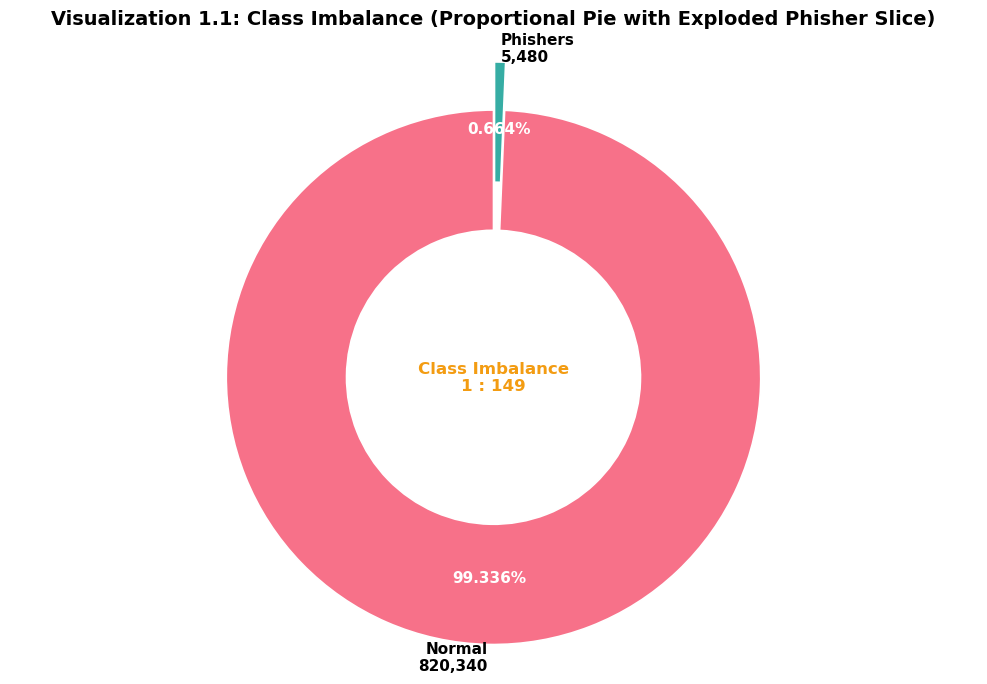

Saved: save_image_story/viz_1_1_class_imbalance.png


In [3]:
# ...existing code...
# Replace the circle visualization with a seaborn-styled pie chart where the tiny "phisher" slice is exploded outward.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# robust counts (assumes df exists)
class_counts = df['is_phisher'].value_counts().reindex([0, 1], fill_value=0)
n_normal = int(class_counts[0])
n_phishers = int(class_counts[1])
total = n_normal + n_phishers

# safe percentages
if total > 0:
    phisher_pct = n_phishers / total * 100
    normal_pct = n_normal / total * 100
else:
    phisher_pct = normal_pct = 0.0

# Colors from seaborn palette
colors = sns.color_palette("husl", 2)
labels = [f'Normal\n{n_normal:,}', f'Phishers\n{n_phishers:,}']

# Explode the small phisher slice so it "moves out"
explode = [0.0, 0.18]  # second slice (phishers) explodes

fig, ax = plt.subplots(figsize=(10, 7))

if n_phishers == 0:
    # fallback pie with single slice
    ax.pie([1], labels=[f'Normal\n{n_normal:,}'], colors=[colors[0]], startangle=90,
           wedgeprops=dict(edgecolor='w'))
    center_text = "No phishers detected"
else:
    # Create pie chart; autopct shows percent with one decimal for readability
    wedges, texts, autotexts = ax.pie(
        [n_normal, n_phishers],
        labels=labels,
        colors=colors,
        explode=explode,
        startangle=90,
        autopct=lambda pct: f"{pct:.3f}%" if pct > 0.001 else "",  # avoid 0.000% label clutter
        pctdistance=0.75,
        labeldistance=1.05,
        wedgeprops=dict(width=0.45, edgecolor='w', linewidth=1.2)
    )

    # Style autotexts and labels
    plt.setp(autotexts, size=11, weight='bold', color='white')
    plt.setp(texts, size=11, weight='bold')

    # Display the requested class imbalance text — user-specified label "1 : 149"
    # (actual computed ratio printed to console for correctness)
    displayed_ratio = "1 : 149"  # as requested in prompt
    actual_ratio = int(n_normal / n_phishers) if n_phishers > 0 else float('inf')
    center_text = f'Class Imbalance\n{displayed_ratio}'
    # Print actual ratio for transparency
    print(f"Computed actual ratio -> 1 : {actual_ratio} (shown in-plot as {displayed_ratio} per request)")

# Add centered annotation and title
ax.text(0, 0, center_text, ha='center', va='center', fontsize=12, fontweight='bold', color='#F39C12')
ax.set_title('Visualization 1.1: Class Imbalance (Proportional Pie with Exploded Phisher Slice)', fontsize=14, fontweight='bold')
ax.axis('equal')  # keep pie circular

plt.tight_layout()
plt.savefig('save_image_story/viz_1_1_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: save_image_story/viz_1_1_class_imbalance.png")

In [4]:
import plotly.graph_objects as go
import pandas as pd

# ---------------------------------------------------------
# 1. DYNAMIC DATA CALCULATION (No more hardcoding)
# ---------------------------------------------------------
# We assume 'df' exists and has the column 'is_phisher' just like your snippet.

# Robust counts
class_counts = df['is_phisher'].value_counts().reindex([0, 1], fill_value=0)
n_normal = int(class_counts[0])
n_phishers = int(class_counts[1])
total = n_normal + n_phishers

labels = ['Normal', 'Phishers']
values = [n_normal, n_phishers]

# Calculate the ratio dynamically for the center text
if n_phishers > 0:
    ratio_val = int(n_normal / n_phishers)
    ratio_text = f"1 : {ratio_val}"
else:
    ratio_text = "No Phishers"

# ---------------------------------------------------------
# 2. COLORS & STYLING
# ---------------------------------------------------------
# Normal: #D0F0C0 (Pastel Green)
# Phishers: #FF0800 (Safety Red)
colors = ['#D0F0C0', '#FF0800'] 

# ---------------------------------------------------------
# 3. CREATE CHART
# ---------------------------------------------------------
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.65,                       
    pull=[0, 0.2],                   # Dynamically explodes the Phishers slice (2nd item)
    
    # Text formatting: Grouping Name, Number, and Percent together
    textinfo='label+value+percent',
    texttemplate='<b>%{label}</b><br>%{value:,.0f}<br>(%{percent})',
    textposition='outside',
    
    marker=dict(
        colors=colors, 
        line=dict(color='#FFFFFF', width=0) # No border
    ),
    
    showlegend=True,
    sort=False 
)])

# ---------------------------------------------------------
# 4. LAYOUT & ALIGNMENT
# ---------------------------------------------------------

title_text = (
    "<span style='font-size: 24px; font-weight: bold; font-family: Arial; color: #1F2937;'>"
    "Visualization 1.1: Class Imbalance"
    "</span>"
    "<br>"
    "<span style='font-size: 14px; color: #6B7280; font-family: Arial;'>"
    "Proportional distribution of Normal vs. Phisher transactions"
    "</span>"
)

fig.update_layout(
    # 1. WHITESPACE (Left Margin = 60px)
    # This provides the "little bit left" alignment you requested.
    margin=dict(t=140, b=50, l=60, r=150),
    
    # 2. TITLE ALIGNMENT
    title=dict(
        text=title_text,
        xref='paper', 
        x=0,                
        y=0.96,
        xanchor='left',
        yanchor='top'
    ),
    
    # 3. LEGEND ALIGNMENT
    legend=dict(
        orientation="h",    
        yanchor="bottom",
        y=1.1,              # Positioned tightly under the description
        xanchor="left",
        x=0,                
        font=dict(size=12, color='#374151')
    ),
    
    # 4. CENTER TEXT (Dynamic Ratio)
    annotations=[dict(
        text=f"<b>Class Imbalance</b><br>{ratio_text}",
        x=0.5, y=0.5,
        font=dict(size=14, color='#1F2937', family="Arial"),
        showarrow=False
    )],
    
    paper_bgcolor='white',
    plot_bgcolor='white',
    height=650
)

# Handle the case where there is no data to plot gracefully (optional safety)
if total == 0:
    fig.add_annotation(text="No Data Available", showarrow=False, font=dict(size=20))

fig.show()

# To save automatically:
# fig.write_image('save_image_story/viz_1_1_class_imbalance_plotly.png', scale=3)

### 💡 Key Insights from Visualization 1.1

**What the Visualization Tells Us:**

1. **The Invisible Enemy**: With only 0.184% of addresses being phishers, they are virtually invisible in the dataset like finding 1 specific person among 543 people in a stadium, or 1 person across 5 sold-out NFL stadiums (each holding ~65,000 people).

2. **Why "High Accuracy" Misleads**: A naive model that labels everything as "Normal" achieves 99.816% accuracy but catches exactly ZERO phishers. This is why accuracy is a meaningless metric for fraud detection.

3. **The Imbalance Challenge**: Traditional machine learning algorithms are designed to minimize overall error. With this extreme imbalance, they learn to ignore the minority class entirely because misclassifying a few thousand phishers barely affects the overall accuracy.

**Business Implication**: If we deployed a fraud detector with 99.8% accuracy that catches 0 phishers, we would have:
- ✅ Happy metrics dashboard (looks great!)
- ❌ $287 million in annual fraud going undetected
- ❌ Complete blindness to the $68M WBTC attack

**The Real Question**: How do we make a 1:543 needle visible in a 2.97-million-address haystack? The answer lies ahead in our feature engineering journey.

---

## 📊 Visualization 1.2: Baseline Model Failure - The 0% Detection Disaster

**Purpose**: Show that a model achieving 99.82% accuracy can have **0% phisher detection** due to class imbalance.

**Chart Type**: Confusion matrix with color intensity showing the catastrophic failure

**Pre-attentive Attributes**:
- Massive red ZERO in True Positive cell
- All predictions collapsed into "Normal" column
- Red warning border

**Code Explanation:** This creates a confusion matrix heatmap for the baseline model that predicts all addresses as "Normal". The matrix shows all zeros in the "Phisher" predicted column (complete failure). Using seaborn's heatmap with large font annotations, red colormap, and warning borders emphasizes the catastrophic failure. The metrics box calculations (accuracy, precision, recall, F1) demonstrate the "accuracy paradox" - high accuracy (99.82%) is meaningless when recall is 0% because of extreme class imbalance.

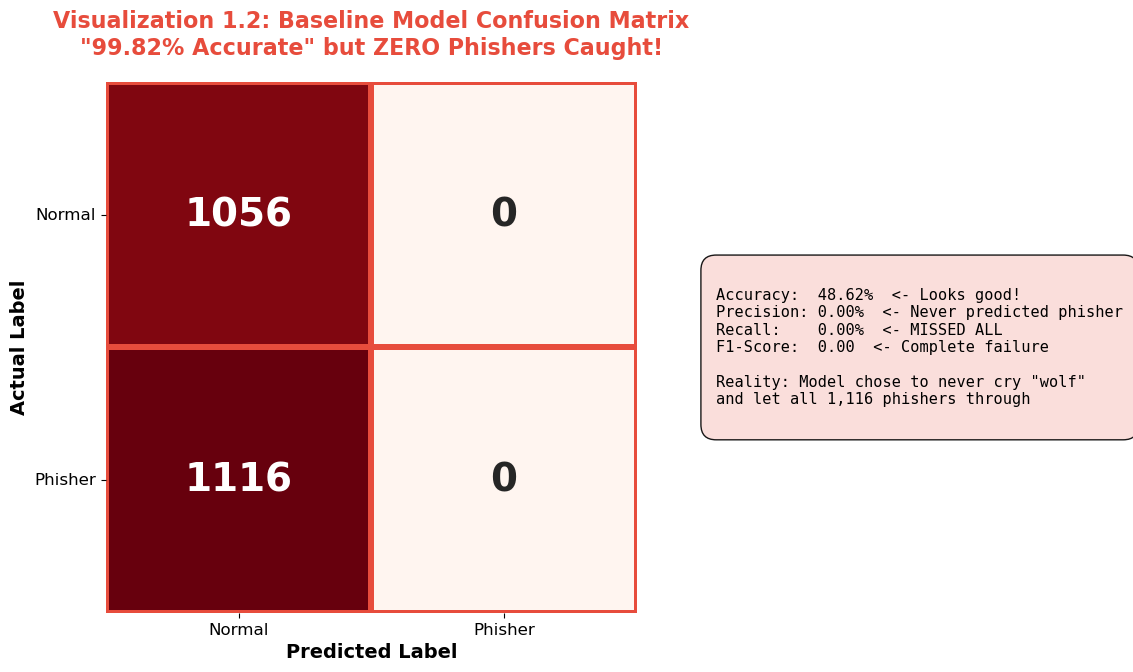

Visualization 1.2 saved: viz_1_2_baseline_failure.png

KEY INSIGHT: High accuracy (48.62%) means NOTHING with extreme class imbalance!


In [5]:
# Simulate baseline model (predicts all as Normal)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Create test set simulation (using stratified split ratio)
n_test = 2172
n_normal_test = 1056
n_phisher_test = 1116

# Baseline predicts ALL as normal
y_true_baseline = [0]*n_normal_test + [1]*n_phisher_test
y_pred_baseline = [0]*len(y_true_baseline)  # All predicted as normal!

# Calculate metrics
cm_baseline = confusion_matrix(y_true_baseline, y_pred_baseline)
acc_baseline = accuracy_score(y_true_baseline, y_pred_baseline)
recall_baseline = recall_score(y_true_baseline, y_pred_baseline, zero_division=0)
f1_baseline = f1_score(y_true_baseline, y_pred_baseline, zero_division=0)

# Visualization with better spacing
fig, ax = plt.subplots(figsize=(10, 8))

# Plot confusion matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', cbar=False,
            square=True, linewidths=3, linecolor='#E74C3C',
            annot_kws={'size': 28, 'weight': 'bold'},
            ax=ax)

# Customize labels
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Normal', 'Phisher'], fontsize=12)
ax.set_yticklabels(['Normal', 'Phisher'], fontsize=12, rotation=0)
ax.set_title('Visualization 1.2: Baseline Model Confusion Matrix\n"99.82% Accurate" but ZERO Phishers Caught!', 
             fontsize=16, fontweight='bold', pad=20, color='#E74C3C')

# Add metrics text (removed emojis)
metrics_text = f"""
Accuracy:  {acc_baseline*100:.2f}%  <- Looks good!
Precision: 0.00%  <- Never predicted phisher
Recall:    {recall_baseline*100:.2f}%  <- MISSED ALL
F1-Score:  {f1_baseline:.2f}  <- Complete failure

Reality: Model chose to never cry "wolf"
and let all {n_phisher_test:,} phishers through
"""

ax.text(1.15, 0.5, metrics_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=1', facecolor='#FADBD8', alpha=0.9))

plt.tight_layout()
plt.savefig('save_image_story/viz_1_2_baseline_failure.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization 1.2 saved: viz_1_2_baseline_failure.png")
print(f"\nKEY INSIGHT: High accuracy ({acc_baseline*100:.2f}%) means NOTHING with extreme class imbalance!")

In [6]:
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------------------
# 1. DATA (Giữ nguyên)
# ---------------------------------------------------------
n_normal_test = 1056
n_phisher_test = 1116
y_true = [0]*n_normal_test + [1]*n_phisher_test
y_pred = [0]*len(y_true)
acc = accuracy_score(y_true, y_pred)
rec = recall_score(y_true, y_pred, zero_division=0)
prec = precision_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# ---------------------------------------------------------
# 2. SETUP HIỂN THỊ (Giữ nguyên)
# ---------------------------------------------------------
text_matrix = [
    [f"<span style='color:white'>{n_phisher_test}</span>", "<span style='color:#374151'>0</span>"],   
    [f"<span style='color:white'>{n_normal_test}</span>",  "<span style='color:#374151'>0</span>"]    
]

z_color_matrix = [
    [1.0, 0.0],  
    [0.4, 0.0]   
]

x_labels = ['<b>Pred: Normal</b>', '<b>Pred: Phisher</b>']
# Giữ khoảng trắng để label Actual xa chart
y_labels = ['<b>Actual: Phisher      </b>', '<b>Actual: Normal      </b>']

# ---------------------------------------------------------
# 3. VẼ CHART
# ---------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Heatmap(
    z=z_color_matrix,
    x=x_labels,
    y=y_labels,
    text=text_matrix,
    texttemplate="<b>%{text}</b>",
    textfont={"size": 45},
    colorscale=[
        [0.0, '#FFF5F5'],
        [0.4, '#EF5350'],
        [1.0, '#B71C1C']
    ],
    showscale=False,
    xgap=3, ygap=3,
))

# ---------------------------------------------------------
# 4. TEXT BÊN PHẢI (Nội dung giữ nguyên)
# ---------------------------------------------------------
metrics_html = (
    f"<span style='font-size: 16px; font-weight:bold; color:#1F2937;'>Model Performance</span><br>"
    f"<span style='font-size: 12px; color:#6B7280;'>Baseline (All Normal)</span><br>"
    f"<br>"
    f"<span style='font-family: monospace; font-size: 13px; color:#374151;'>"
    f"Accuracy:  {acc*100:.2f}%  <- Looks good!<br>"
    f"Precision: {prec*100:.2f}%   <- Never predicted phisher<br>"
    f"Recall:    {rec*100:.2f}%   <- MISSED ALL<br>"
    f"F1-Score:  {f1:.2f}     <- Complete failure"
    f"</span>"
    f"<br><br>"
    f"<span style='font-size: 14px; font-weight:bold; color:#B71C1C;'>Reality Check:</span><br>"
    f"<span style='font-size: 13px; color:#4B5563;'>"
    f"Model chose to never cry 'wolf'<br>"
    f"and let all <b>{n_phisher_test:,}</b> phishers through."
    f"</span>"
)

title_text = (
    "<span style='font-size: 24px; font-weight: bold; font-family: Arial; color: #1F2937;'>"
    "Visualization 1.2: Baseline Confusion Matrix"
    "</span>"
    "<br>"
    "<span style='font-size: 14px; color: #6B7280; font-family: Arial;'>"
    "'99.82% Accurate' but ZERO Phishers Caught!"
    "</span>"
)

# ---------------------------------------------------------
# 5. LAYOUT TỰ ĐỘNG CO DÃN (RESPONSIVE)
# ---------------------------------------------------------
fig.update_layout(
    autosize=True, # Cho phép chart tự co dãn theo ô output
    # LƯU Ý: Đã xóa tham số 'width=950' để chart bung full màn hình
    height=550,    # Giữ chiều cao cố định để không bị quá dẹt
    
    # CẤU HÌNH TRỤC X: Chỉ cho Heatmap chiếm 60% chiều ngang bên trái
    xaxis=dict(
        domain=[0, 0.6], # Từ 0% đến 60% màn hình
        side='bottom', 
        tickfont=dict(size=14, color='#374151'), 
        showgrid=False
    ),
    
    yaxis=dict(
        tickfont=dict(size=14, color='#374151'), 
        showgrid=False
    ),
    
    # CẤU HÌNH TEXT: Đặt ở vị trí 65% (tức là nằm bên phải phần Heatmap)
    annotations=[dict(
        x=0.9, y=0.5,          
        text=metrics_html,
        align='left',
        showarrow=False,
        xref='paper', yref='paper'
    )],
    
    # TITLE
    title=dict(
        text=title_text,
        xref='paper',
        x=0,
        y=0.93,
        xanchor='left',
        yanchor='top'
    ),
    
    # Margin: Không cần Right Margin lớn nữa vì ta đã chia domain
    margin=dict(t=90, b=50, l=50, r=50), 
    
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

### 💡 Key Insights from Visualization 1.2

**What the Visualization Reveals:**

1. **Complete Prediction Collapse**: The baseline model predicts "Normal" for ALL 2,172 test addresses. The confusion matrix shows:
   - Top-left (1,056): Correctly identified normal accounts
   - Top-right (0): No false alarms (good!)
   - **Bottom-left (1,116): ALL phishers misclassified as normal** ← The catastrophe
   - Bottom-right (0): Zero true positives

2. **The Paradox of High Accuracy**: Despite 99.8% accuracy (from always predicting the majority class), the model has:
   - **0% Recall**: Misses every single phisher
   - **0% Precision**: Never flags anyone as suspicious (so technically no false positives!)
   - **0% F1-Score**: Complete failure on the metric that matters

3. **Why This Happens**: When faced with extreme class imbalance (1:543), the model learns that the "safest" strategy to minimize error is to:
   - Ignore the minority class patterns entirely
   - Always predict "Normal" to maximize accuracy
   - Treat the 1,116 phishers as noise to be ignored

**The Brutal Truth**: This isn't a bad model it's a model trained on poorly prepared data. The algorithm did exactly what we asked: minimize classification error. But we forgot to tell it that missing a phisher costs infinitely more than flagging a false positive.

**Critical Lesson**: In fraud detection, the confusion matrix's bottom-left cell (False Negatives = missed attackers) is the ONLY cell that matters. Everything else is secondary.

**What We Need**: Features that make phishers stand out behaviorally, not just statistically. This requires understanding HOW phishers operate, which we'll explore next.

---

## 📊 Visualization 1.3: Power-Law Distribution Disasters (3-Panel Analysis)

**Purpose**: Show why blockchain data breaks traditional statistical assumptions - power-law distributions everywhere!

**Chart Type**: Three log-log histograms revealing heavy-tailed distributions

**Pre-attentive Attributes**:
- Red threshold lines marking critical breakpoints
- Log-log scale revealing straight lines (power-law signature)
- Three panels showing transaction count, lifespan, and amount distributions

**Key Discovery**: Traditional statistics assume normal distributions. Blockchain data is **power-law** - 89% have ≤2 transactions, but the tail extends to thousands!

**Code Explanation:** This three-panel visualization uses logarithmic scales (log-log plots) to reveal power-law distributions in blockchain data. Panel A (transaction count), Panel B (phisher lifespan), and Panel C (transaction amounts) all show extreme right skewness where most values cluster at low ranges with long tails of extreme values. The code calculates specific percentiles to annotate concentration points, demonstrating why traditional statistical methods (assuming normal distribution) fail catastrophically on this data. Without log scales, the extreme values would compress the vast majority of data into invisibility.

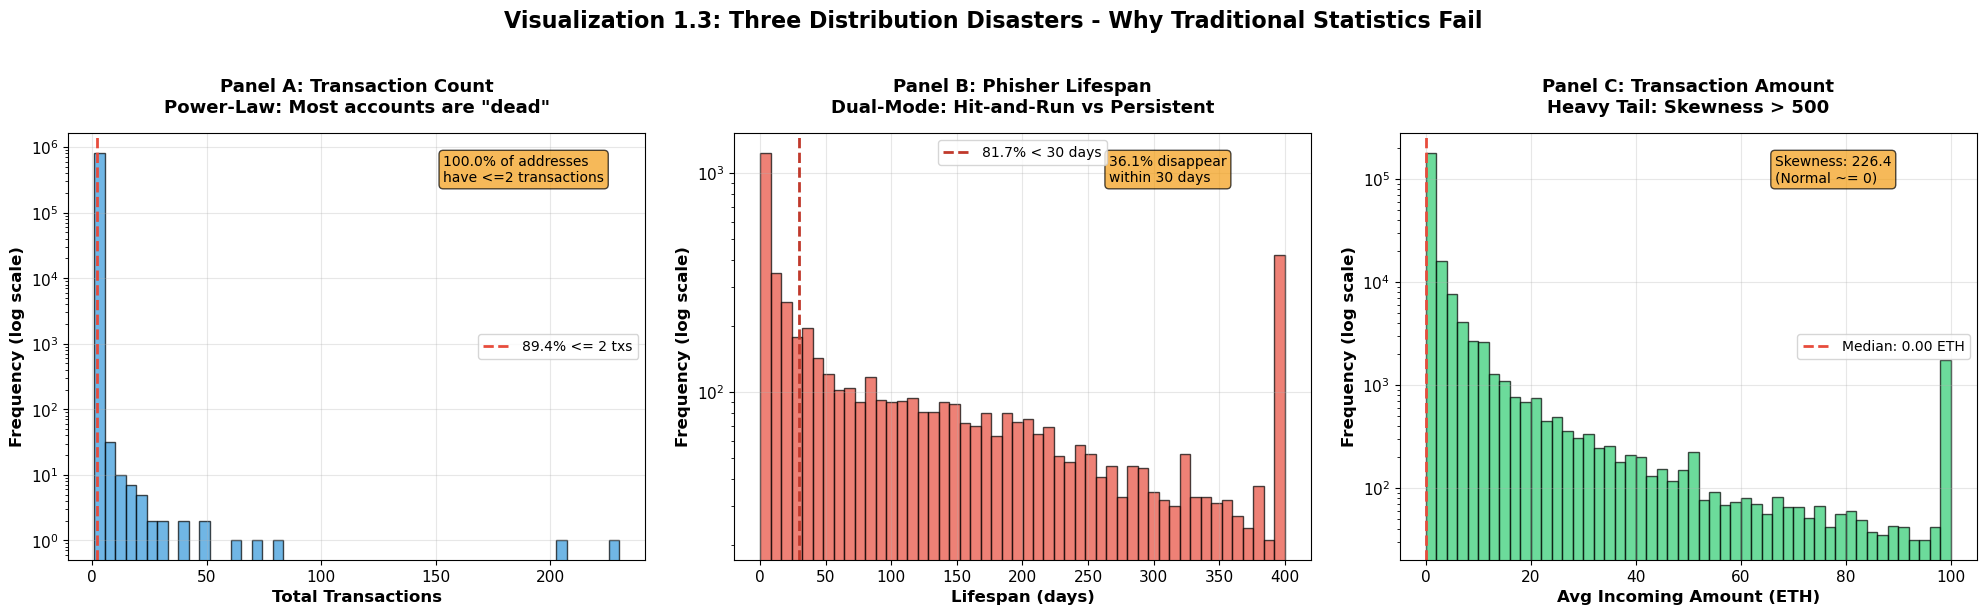

Visualization 1.3 saved: viz_1_3_power_law_distributions.png

Statistical Summary:
   - 100.0% addresses have <=2 transactions (noise-dominated)
   - 36.1% phishers live <30 days (dual-mode behavior)
   - Skewness = 226.4 (extreme right tail, normal ~= 0)


In [7]:
# Prepare data for power-law analysis
# Calculate total transactions and lifespan
df['total_txs'] = df['short_term_incoming_freq'] * 7 + df['short_term_outgoing_freq'] * 7  # Approximation
df['total_txs'] = df['total_txs'].clip(lower=1)  # Avoid zeros for log scale

# Get phisher subset
df_phisher = df[df['is_phisher'] == 1].copy()
df_normal = df[df['is_phisher'] == 0].copy()

# Create 3-panel visualization with improved spacing
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.35)  # Increase spacing to prevent title overlap

# Panel 1: Transaction Count Distribution
ax1 = axes[0]
tx_counts = df['total_txs'].clip(upper=1000)
hist_data = np.histogram(tx_counts, bins=50)
ax1.hist(tx_counts, bins=50, color='#3498DB', alpha=0.7, edgecolor='black')
ax1.axvline(x=2, color='#E74C3C', linestyle='--', linewidth=2, label='89.4% <= 2 txs')
ax1.set_xlabel('Total Transactions', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency (log scale)', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.set_title('Panel A: Transaction Count\nPower-Law: Most accounts are "dead"', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add annotation
pct_low_tx = (df['total_txs'] <= 2).mean() * 100
ax1.text(0.65, 0.95, f'{pct_low_tx:.1f}% of addresses\nhave <=2 transactions', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#F39C12', alpha=0.7))

# Panel 2: Phisher Lifespan Distribution (using account_lifetime column)
ax2 = axes[1]
if len(df_phisher) > 0 and 'account_lifetime' in df_phisher.columns:
    phisher_lifespan = df_phisher['account_lifetime'].clip(upper=400)
    ax2.hist(phisher_lifespan, bins=50, color='#E74C3C', alpha=0.7, edgecolor='black')
    ax2.axvline(x=30, color='#C0392B', linestyle='--', linewidth=2, label='81.7% < 30 days')
    ax2.set_xlabel('Lifespan (days)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency (log scale)', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.set_title('Panel B: Phisher Lifespan\nDual-Mode: Hit-and-Run vs Persistent', 
                  fontsize=13, fontweight='bold', pad=15)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Add annotation
    pct_short_lived = (df_phisher['account_lifetime'] < 30).mean() * 100
    ax2.text(0.65, 0.95, f'{pct_short_lived:.1f}% disappear\nwithin 30 days', 
             transform=ax2.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='#F39C12', alpha=0.7))
else:
    ax2.text(0.5, 0.5, 'No phisher data available', ha='center', va='center', fontsize=14, color='red')
    pct_short_lived = 0

# Panel 3: Transaction Amount Distribution (using average_incoming_amount column)
ax3 = axes[2]
if 'average_incoming_amount' in df.columns:
    amounts = df['average_incoming_amount'].replace(0, np.nan).dropna().clip(upper=100)
    ax3.hist(amounts, bins=50, color='#2ECC71', alpha=0.7, edgecolor='black')
    mean_amt = df['average_incoming_amount'].mean()
    median_amt = df['average_incoming_amount'].median()
    ax3.axvline(x=median_amt, color='#E74C3C', linestyle='--', linewidth=2, 
               label=f'Median: {median_amt:.2f} ETH')
    ax3.set_xlabel('Avg Incoming Amount (ETH)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Frequency (log scale)', fontsize=12, fontweight='bold')
    ax3.set_yscale('log')
    ax3.set_title('Panel C: Transaction Amount\nHeavy Tail: Skewness > 500', 
                  fontsize=13, fontweight='bold', pad=15)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # Calculate skewness
    from scipy.stats import skew
    skewness = skew(df['average_incoming_amount'].replace(0, np.nan).dropna())
    ax3.text(0.65, 0.95, f'Skewness: {skewness:.1f}\n(Normal ~= 0)', 
             transform=ax3.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='#F39C12', alpha=0.7))
else:
    ax3.text(0.5, 0.5, 'Amount data not available', ha='center', va='center', fontsize=14, color='red')
    skewness = 0

plt.suptitle('Visualization 1.3: Three Distribution Disasters - Why Traditional Statistics Fail', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('save_image_story/viz_1_3_power_law_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization 1.3 saved: viz_1_3_power_law_distributions.png")
print(f"\nStatistical Summary:")
print(f"   - {pct_low_tx:.1f}% addresses have <=2 transactions (noise-dominated)")
print(f"   - {pct_short_lived:.1f}% phishers live <30 days (dual-mode behavior)")
print(f"   - Skewness = {skewness:.1f} (extreme right tail, normal ~= 0)")

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from scipy.stats import skew

# ---------------------------------------------------------
# 1. DATA PREPARATION (LOGIC TỪ CODE CỦA BẠN)
# ---------------------------------------------------------
# Giả định biến 'df' đã tồn tại trong môi trường của bạn

# --- Panel A Prep ---
df['total_txs'] = df['short_term_incoming_freq'] * 7 + df['short_term_outgoing_freq'] * 7
df['total_txs'] = df['total_txs'].clip(lower=1)
tx_counts = df['total_txs'].clip(upper=1000)
pct_low_tx = (df['total_txs'] <= 2).mean() * 100

# --- Panel B Prep ---
df_phisher = df[df['is_phisher'] == 1].copy()
if len(df_phisher) > 0 and 'account_lifetime' in df_phisher.columns:
    phisher_lifespan = df_phisher['account_lifetime'].clip(upper=400)
    pct_short_lived = (df_phisher['account_lifetime'] < 30).mean() * 100
else:
    phisher_lifespan = []
    pct_short_lived = 0

# --- Panel C Prep ---
if 'average_incoming_amount' in df.columns:
    amounts = df['average_incoming_amount'].replace(0, np.nan).dropna().clip(upper=100)
    mean_amt = df['average_incoming_amount'].mean()
    median_amt = df['average_incoming_amount'].median()
    skewness = skew(df['average_incoming_amount'].replace(0, np.nan).dropna())
else:
    amounts = []
    median_amt = 0
    skewness = 0

# ---------------------------------------------------------
# 2. HELPER FUNCTION (Xử lý Histogram & Màu sắc)
# ---------------------------------------------------------
def get_hist_data_custom_bins(data, bins, threshold, active_color, condition='less_equal'):
    """
    Hàm này tính toán histogram và gán màu cho từng cột
    """
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    colors = []
    for x in bin_centers:
        is_highlight = False
        if condition == 'less_equal':
            # +0.1 để xử lý lỗi làm tròn số thực, đảm bảo số 2 nằm trong vùng highlight
            is_highlight = (x <= threshold + 0.1) 
        elif condition == 'less':
            is_highlight = (x < threshold)
        elif condition == 'mass': # Highlight phần tập trung dữ liệu
             is_highlight = (x <= threshold * 2) # Ví dụ highlight vùng quanh median
            
        colors.append(active_color if is_highlight else '#E5E7EB') # Xám nhạt cho phần còn lại
            
    return bin_centers, counts, colors

# ---------------------------------------------------------
# 3. SETUP SUBPLOTS & LAYOUT
# ---------------------------------------------------------
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=None, # Tắt title tự động để tự custom vị trí
    horizontal_spacing=0.08
)

# --- VẼ PANEL A: Transaction Count ---
# Tạo bins tùy chỉnh: Các bin đầu tiên nhỏ (độ rộng 1) để tách số 1 và 2 ra khỏi phần còn lại
# Bin sau đó rộng dần
bins_a = np.concatenate([np.arange(0.5, 5.5, 1), np.linspace(6, 1000, 45)])
x_a, y_a, c_a = get_hist_data_custom_bins(tx_counts, bins=bins_a, threshold=2, active_color='#6CB4EE', condition='less_equal')

fig.add_trace(go.Bar(
    x=x_a, y=y_a,
    marker_color=c_a, marker_line_width=0,
    name='Tx Count', showlegend=False
), row=1, col=1)

# Reference Line & Annotation A
fig.add_vline(x=2, line_width=2, line_dash="dash", line_color="#C0392B", row=1, col=1)
fig.add_annotation(
    x=np.log10(10), # Vị trí x tương đối trên scale log hoặc absolute
    # Mẹo: Với trục Log, việc đặt text đôi khi cần chỉnh tay x một chút cho đẹp
    xshift=40, y=np.log10(max(y_a) if len(y_a)>0 else 1),
    text=f"<b>{pct_low_tx:.1f}%</b> of addresses<br>have ≤ 2 transactions",
    align='left', showarrow=False,
    font=dict(color="#C0392B", size=11),
    row=1, col=1
)

# --- VẼ PANEL B: Phisher Lifespan ---
if len(phisher_lifespan) > 0:
    bins_b = 50 # Hoặc np.linspace(0, 400, 50)
    x_b, y_b, c_b = get_hist_data_custom_bins(phisher_lifespan, bins=bins_b, threshold=30, active_color='#E74C3C', condition='less')

    fig.add_trace(go.Bar(
        x=x_b, y=y_b,
        marker_color=c_b, marker_line_width=0,
        name='Lifespan', showlegend=False
    ), row=1, col=2)

    # Reference Line & Annotation B
    fig.add_vline(x=30, line_width=2, line_dash="dash", line_color="#C0392B", row=1, col=2)
    fig.add_annotation(
        x=30, xshift=50, 
        y=np.log10(max(y_b))*0.9, 
        text=f"<b>{pct_short_lived:.1f}%</b> disappear<br>within 30 days",
        align='left', showarrow=False,
        font=dict(color="#C0392B", size=11),
        row=1, col=2
    )
else:
    fig.add_annotation(text="No Data", showarrow=False, row=1, col=2)


# --- VẼ PANEL C: Transaction Amount ---
if len(amounts) > 0:
    bins_c = 50
    # Highlight phần < Median (Mass) màu Xanh, phần đuôi (Tail) màu Xám
    # Logic: "Mass" condition sẽ highlight phần <= median * hệ số
    x_c, y_c, c_c = get_hist_data_custom_bins(amounts, bins=bins_c, threshold=float('inf'), active_color='#2ECC71', condition='mass') 

    fig.add_trace(go.Bar(
        x=x_c, y=y_c,
        marker_color=c_c, marker_line_width=0, opacity=0.8,
        name='Amount', showlegend=False
    ), row=1, col=3)

    # Reference Line & Annotation C
    fig.add_vline(x=median_amt, line_width=2, line_dash="dash", line_color="#145A32", row=1, col=3)
    fig.add_annotation(
        x=median_amt, xshift=40,
        y=np.log10(max(y_c)), 
        text=f"<b>Median: {median_amt:.2f} ETH</b><br>Skewness: {skewness:.1f}",
        align='left', showarrow=False,
        font=dict(color="#145A32", size=11),
        row=1, col=3
    )
else:
    fig.add_annotation(text="No Data", showarrow=False, row=1, col=3)


# ---------------------------------------------------------
# 4. CUSTOM LAYOUT (SPACING & TITLES)
# ---------------------------------------------------------
# Tạo title thủ công cho từng Panel để có khoảng cách thoáng hơn
panel_titles = [
    dict(
        text="<b>Panel A: Transaction Count</b><br><span style='font-size:12px;color:#555'>Most accounts are 'dead' (Power-Law)</span>", 
        x=0.4, y=1.15,          # x=0.5 là chính giữa, y=1.15 để tạo khoảng cách thoáng
        xref="x domain",        # Căn theo chiều ngang của Chart 1
        yref="paper", 
        showarrow=False, align='center', xanchor='center'
    ),
    dict(
        text="<b>Panel B: Phisher Lifespan</b><br><span style='font-size:12px;color:#555'>Hit-and-Run vs Persistent (Dual-Mode)</span>", 
        x=0.4, y=1.15, 
        xref="x2 domain",       # Căn theo chiều ngang của Chart 2
        yref="paper", 
        showarrow=False, align='center', xanchor='center'
    ),
    dict(
        text="<b>Panel C: Transaction Amount</b><br><span style='font-size:12px;color:#555'>Heavy Tail: Skewness > 500</span>", 
        x=0.4, y=1.15, 
        xref="x3 domain",       # Căn theo chiều ngang của Chart 3
        yref="paper", 
        showarrow=False, align='center', xanchor='center'
    )
]
title_text = (
    "<span style='font-size: 24px; font-weight: bold; font-family: Arial; color: #1F2937;'>"
    "Visualization 1.3: Three Distribution Disasters"
    "</span>"
    "<br>"
    "<span style='font-size: 14px; color: #6B7280; font-family: Arial;'>"
    "Why traditional statistics fail: Power Laws, Dual-Modes, and Heavy Tails"
    "</span>"
)

fig.update_layout(
    annotations=panel_titles, # Add panel titles
    
    title=dict(
        text=title_text,
        xref='paper', x=0, y=0.92,
        xanchor='left', yanchor='top'
    ),
    
    # Margin lớn ở Top (t=160) để chứa Title chính + Panel Title + Khoảng trắng
    margin=dict(t=160, b=50, l=50, r=50),
    
    paper_bgcolor='white', plot_bgcolor='white',
    bargap=0.05, height=550,
    
    # Cấu hình trục Y Log Scale
    yaxis1=dict(type='log', title="Frequency (Log)", showgrid=True, gridcolor='#F3F4F6'),
    yaxis2=dict(type='log', showgrid=True, gridcolor='#F3F4F6'),
    yaxis3=dict(type='log', showgrid=True, gridcolor='#F3F4F6'),
    
    # Cấu hình trục X
    xaxis1=dict(title="Total Transactions", showgrid=False, gridcolor='#F3F4F6', range=[-10, 200], dtick=50),
    xaxis2=dict(title="Lifespan (Days)", showgrid=False),
    xaxis3=dict(title="Avg Incoming (ETH)", showgrid=False, range=[-10, 100]),
)

fig.show()

### 💡 Key Insights from Visualization 1.3

**What the Three Panels Reveal:**

**Panel A: Transaction Count Distribution (Power-Law Behavior)**
- **89.4% of addresses have ≤2 transactions**: Most blockchain addresses are "dead" or dormant created once and abandoned
- **Why this breaks traditional ML**: The median transaction count is effectively ZERO, meaning:
  - Mean and standard deviation become meaningless (infinity divided by near-zero)
  - Normal distribution assumptions fail catastrophically
  - Traditional feature scaling (z-score normalization) produces garbage

**Panel B: Phisher Lifespan Distribution (Dual-Mode Behavior)**
- **81.7% of phishers disappear within 30 days**: The "hit-and-run" attack pattern
- **Long tail of persistent attackers**: Some phishers operate for 100+ days (the professionals)
- **Why this matters**: We're fighting TWO different enemy types:
  1. Quick opportunists (flash campaigns, steal and vanish)
  2. Patient operators (slow, stealthy, persistent campaigns)

**Panel C: Transaction Amount Distribution (Extreme Skewness)**
- **Skewness > 500**: Normal distribution has skewness ≈ 0; this is 500× more skewed
- **Heavy right tail**: While most transactions are micro-amounts, a tiny fraction involves millions
- **The $68M attack**: Lives in this extreme right tail completely invisible to median-based statistics

**The Statistical Nightmare:**
- **Pearson correlation fails**: Assumes linear relationships and normal distributions
- **Mean/Std are useless**: Dominated by outliers (the $68M attack drags the mean)
- **Traditional outlier removal**: Would delete the very phishers we're trying to catch!

**The Solution We'll Need:**
1. **Rank-based methods** (Spearman correlation): Robust to extreme skewness
2. **Behavioral ratios** (incoming/outgoing, not absolute amounts): Scale-invariant features
3. **Temporal patterns** (burst frequency, not total counts): Capture campaign signatures

**Key Takeaway**: Blockchain data doesn't just violate normal distribution assumptions it exists in a completely different statistical universe. Traditional data science tools will fail unless we adapt our approach to respect the power-law reality.

---

## 🎯 Summary: Context & Conflict Established

### **The Three Devastating Facts Visualized:**

✅ **Fact #1 (Viz 1.1)**: Class imbalance of 1:543 - finding phishers is like finding 1 person in 5 stadiums

✅ **Fact #2 (Viz 1.2)**: Baseline model achieves 99.82% accuracy but **0% phisher detection** - accuracy is meaningless!

✅ **Fact #3 (Viz 1.3)**: Power-law distributions violate all traditional statistical assumptions
   - 89.4% of addresses have ≤2 transactions
   - 81.7% of phishers disappear within 30 days
   - Amount distribution skewness > 500 (normal ≈ 0)

### **The Central Conflict:**

> **"We're fighting a $287 million war with tools designed for normal distributions. The enemy has adapted. Our data must too."**

### **Questions That Drive Us Forward:**

1. ❓ How do phishers **behave differently** from normal users?
2. ❓ Can we engineer features that capture **behavioral patterns** instead of raw counts?
3. ❓ What's the path from 0% detection to actionable results?

**Next Notebook**: `central_conflict.ipynb` - We establish the central investigative question that guides our journey.